# Task 2: Exploratory Data Analysis
**Ethiopia Financial Inclusion Forecasting — Selam Analytics**

This notebook analyzes patterns in Ethiopia's financial inclusion data (enriched in Task 1) to
understand what drives Access (account ownership) and Usage (digital payments), and to surface
hypotheses for the Task 3 event-impact model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_unified_data, load_reference_codes, get_observations, get_events, get_impact_links, get_targets

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_unified_data()
ref = load_reference_codes()
obs = get_observations(df)
events = get_events(df)
links = get_impact_links(df)
targets = get_targets(df)

print(f"Total records: {len(df)}  |  observations: {len(obs)}  events: {len(events)}  impact_links: {len(links)}  targets: {len(targets)}")

Total records: 69  |  observations: 39  events: 11  impact_links: 16  targets: 3


## 1. Dataset Overview

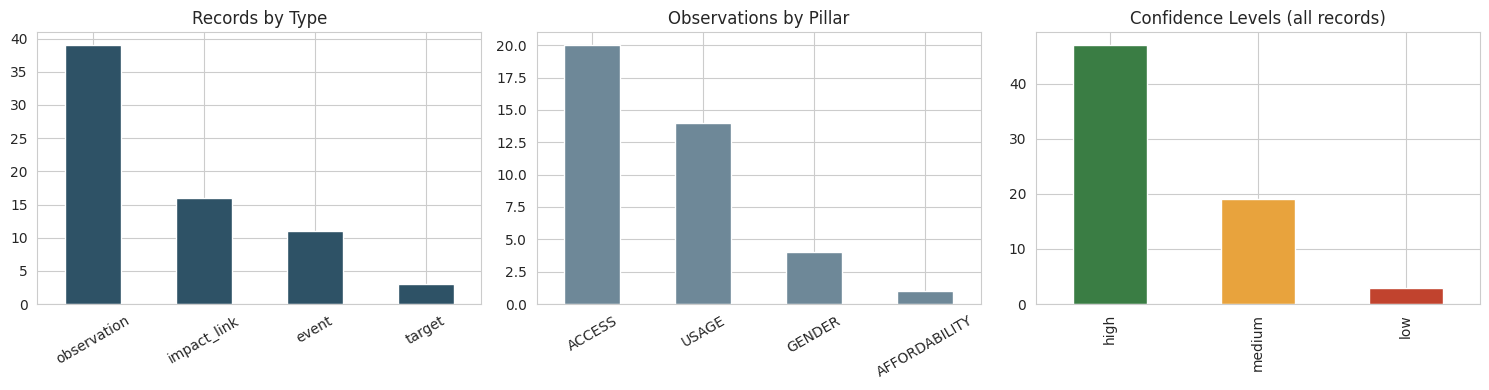

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color='#2E5266')
axes[0].set_title('Records by Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

obs['pillar'].value_counts().plot(kind='bar', ax=axes[1], color='#6E8898')
axes[1].set_title('Observations by Pillar')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

df['confidence'].value_counts().reindex(['high','medium','low']).plot(
    kind='bar', ax=axes[2], color=['#3A7D44','#E8A33D','#C1432E'])
axes[2].set_title('Confidence Levels (all records)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / "01_dataset_overview.png", bbox_inches='tight')
plt.show()

**Data quality note:** 47 of 69 records (68%) are `high` confidence, mostly official survey/operator/regulator
sources from the starter dataset. The 3 `low`-confidence records are all from Task 1 enrichment (see
`data/data_enrichment_log.md`) where secondary sources conflicted with each other or the project brief.

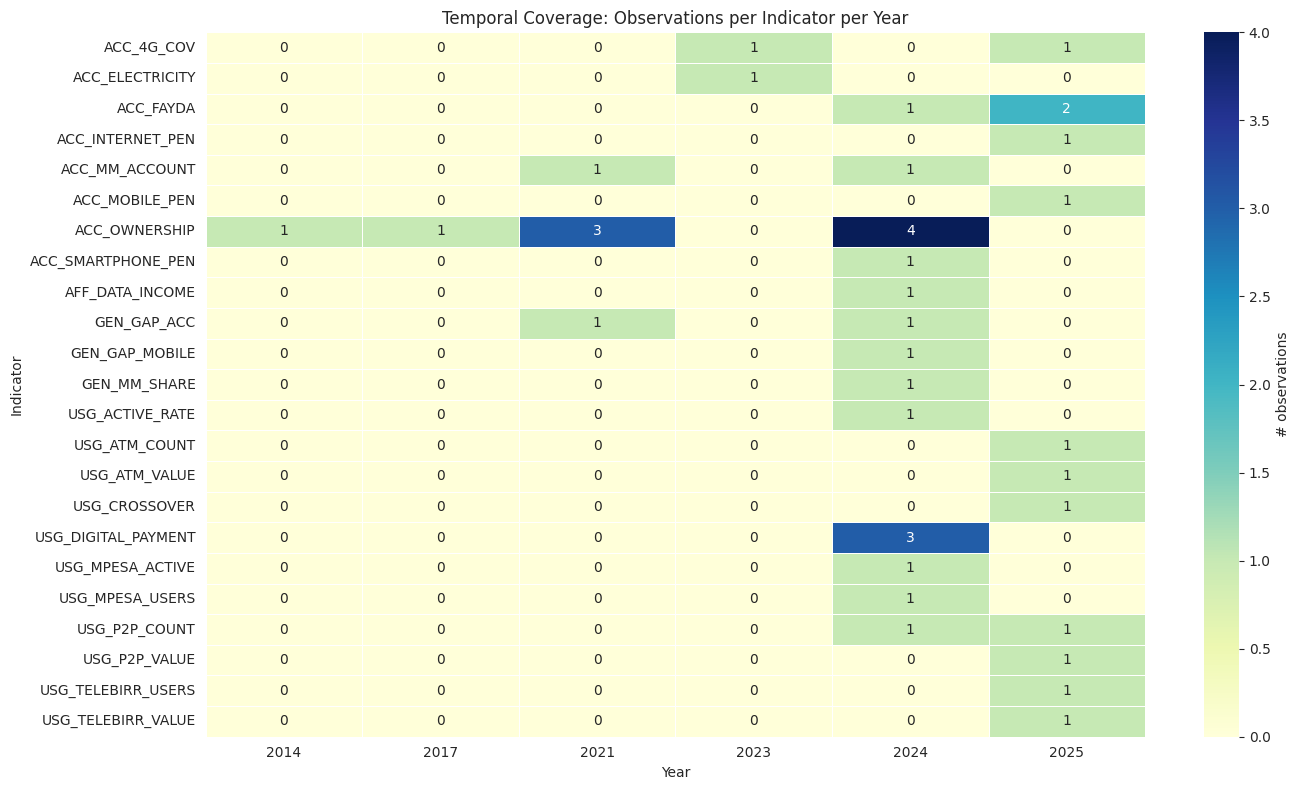


Sparsest indicators (1 data point only — cannot show a trend, only a snapshot):
['ACC_ELECTRICITY', 'ACC_INTERNET_PEN', 'ACC_MOBILE_PEN', 'ACC_SMARTPHONE_PEN', 'AFF_DATA_INCOME', 'GEN_GAP_MOBILE', 'GEN_MM_SHARE', 'USG_ACTIVE_RATE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_MPESA_ACTIVE', 'USG_MPESA_USERS', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE']


In [3]:
# Temporal coverage: which years have data for which indicators?
obs_years = obs.copy()
obs_years['year'] = pd.to_datetime(obs_years['observation_date']).dt.year
coverage = obs_years.pivot_table(index='indicator_code', columns='year', values='value_numeric', aggfunc='count')
coverage = coverage.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(coverage, cmap="YlGnBu", cbar_kws={'label': '# observations'}, linewidths=0.5, ax=ax, annot=True, fmt='d')
ax.set_title('Temporal Coverage: Observations per Indicator per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Indicator')
plt.tight_layout()
plt.savefig(FIG_DIR / "02_temporal_coverage.png", bbox_inches='tight')
plt.show()

print("\nSparsest indicators (1 data point only — cannot show a trend, only a snapshot):")
print(coverage[coverage.sum(axis=1) == 1].index.tolist())

**Key gap:** Most indicators have only 1-2 observations. Only `ACC_OWNERSHIP` (the core Access target)
has enough points (5, spanning 2014-2024) to fit any kind of trend. This is the central challenge for
Task 4 forecasting and is why the brief calls for wide uncertainty bounds.

## 2. Access Analysis

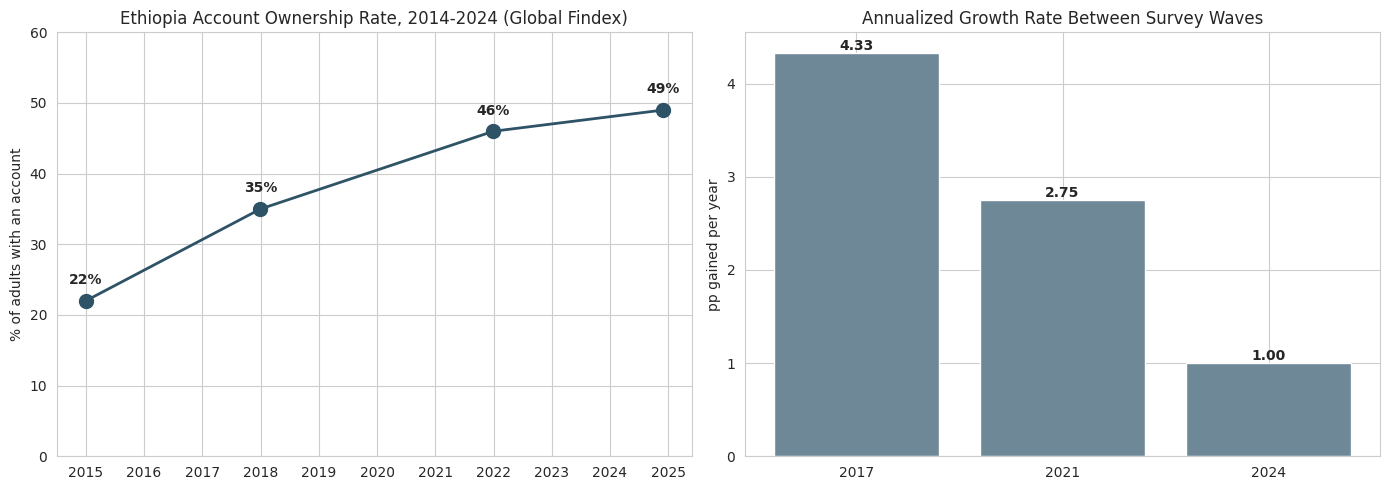

  observation_date  value_numeric  pp_change  years_gap  pp_per_year
0       2014-12-31           22.0        NaN        NaN          NaN
1       2017-12-31           35.0       13.0        3.0     4.333333
2       2021-12-31           46.0       11.0        4.0     2.750000
3       2024-11-29           49.0        3.0        3.0     1.000000


In [4]:
acc_national = obs[(obs.indicator_code == 'ACC_OWNERSHIP') & (obs.gender == 'all') & (obs.location == 'national')].copy()
acc_national['observation_date'] = pd.to_datetime(acc_national['observation_date'])
acc_national = acc_national.sort_values('observation_date').reset_index(drop=True)
acc_national['pp_change'] = acc_national['value_numeric'].diff()
acc_national['years_gap'] = acc_national['observation_date'].dt.year.diff()
acc_national['pp_per_year'] = acc_national['pp_change'] / acc_national['years_gap']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc_national['observation_date'], acc_national['value_numeric'], marker='o', markersize=10, linewidth=2, color='#2E5266')
for _, row in acc_national.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                      textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold')
axes[0].set_title("Ethiopia Account Ownership Rate, 2014-2024 (Global Findex)")
axes[0].set_ylabel("% of adults with an account")
axes[0].set_ylim(0, 60)

bars = axes[1].bar(acc_national['observation_date'].dt.year.astype(str)[1:], acc_national['pp_per_year'][1:], color='#6E8898')
axes[1].set_title("Annualized Growth Rate Between Survey Waves")
axes[1].set_ylabel("pp gained per year")
for bar, val in zip(bars, acc_national['pp_per_year'][1:]):
    axes[1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / "03_access_trajectory_growth.png", bbox_inches='tight')
plt.show()

print(acc_national[['observation_date', 'value_numeric', 'pp_change', 'years_gap', 'pp_per_year']])

**The 2021-2024 slowdown is stark and quantifiable:** growth per year fell from **4.33 pp/year (2014-17)**
to **2.75 pp/year (2017-21)** to just **1.00 pp/year (2021-24)** — even as mobile money accounts multiplied.
This is the central puzzle Task 2 asks us to investigate (see Section 6 for hypotheses).

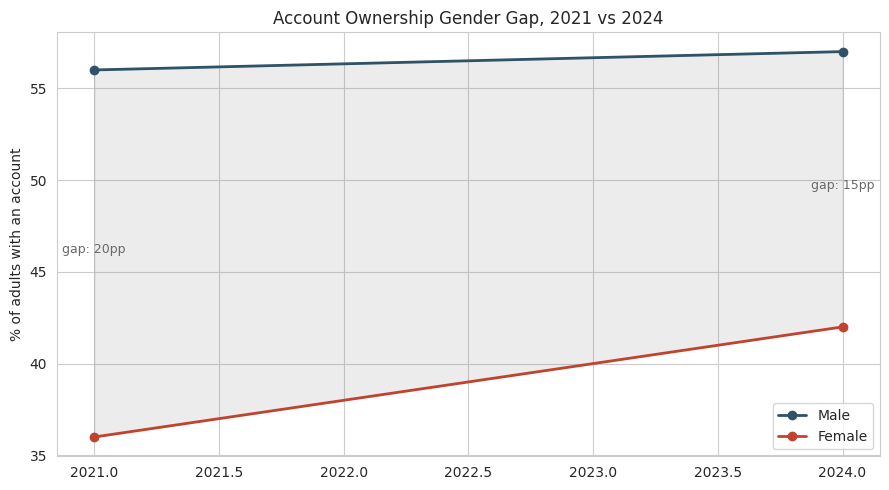

gender  female  male
year                
2021      36.0  56.0
2024      42.0  57.0

Direct GEN_GAP_ACC records (primary series per data_enrichment_log.md):
   observation_date  value_numeric         source_name confidence
26       2021-12-31           20.0  Global Findex 2021       high
27       2024-11-29           18.0  Global Findex 2024     medium


In [5]:
# Gender gap over time
gender_acc = obs[(obs.indicator_code == 'ACC_OWNERSHIP') & (obs.gender.isin(['male', 'female'])) & (obs.location == 'national')].copy()
gender_acc['observation_date'] = pd.to_datetime(gender_acc['observation_date'])
gender_acc['year'] = gender_acc['observation_date'].dt.year
gender_pivot = gender_acc.pivot_table(index='year', columns='gender', values='value_numeric')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gender_pivot.index, gender_pivot['male'], marker='o', label='Male', color='#2E5266', linewidth=2)
ax.plot(gender_pivot.index, gender_pivot['female'], marker='o', label='Female', color='#C1432E', linewidth=2)
ax.fill_between(gender_pivot.index, gender_pivot['male'], gender_pivot['female'], alpha=0.15, color='gray')
for yr in gender_pivot.index:
    gap = gender_pivot.loc[yr, 'male'] - gender_pivot.loc[yr, 'female']
    ax.annotate(f"gap: {gap:.0f}pp", (yr, (gender_pivot.loc[yr,'male']+gender_pivot.loc[yr,'female'])/2),
                ha='center', fontsize=9, color='dimgray')
ax.set_title("Account Ownership Gender Gap, 2021 vs 2024")
ax.set_ylabel("% of adults with an account")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_gender_gap.png", bbox_inches='tight')
plt.show()
print(gender_pivot)

# GEN_GAP_ACC direct series (from starter dataset, higher confidence)
gap_direct = obs[obs.indicator_code == 'GEN_GAP_ACC'][['observation_date','value_numeric','source_name','confidence']]
print("\nDirect GEN_GAP_ACC records (primary series per data_enrichment_log.md):")
print(gap_direct)

**Gender gap is not narrowing.** Using the starter dataset's own `GEN_GAP_ACC` series (the primary,
higher-confidence source per the Task 1 enrichment log), the gap moved from 20pp (2021) to 18pp (2024)
— a marginal 2pp narrowing over 3 years. The enrichment-sourced male/female series (56/36 in 2021,
57/42 in 2024) tells a similar story qualitatively even though the exact gap differs by source
(see data quality note in the enrichment log).

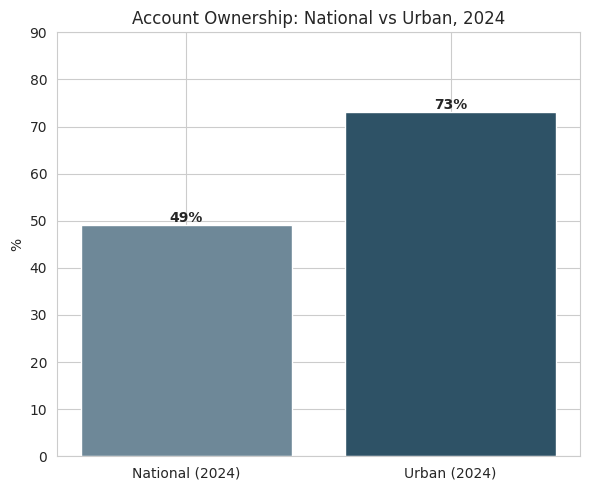

Urban (73%) is 24pp above the national average (49%),
implying rural ownership sits meaningfully below 49% (exact rural figure not directly available -- see enrichment log).


In [6]:
# Urban vs national
urban_2024 = obs[(obs.indicator_code=='ACC_OWNERSHIP') & (obs.location=='urban')]['value_numeric'].values
national_2024 = obs[(obs.indicator_code=='ACC_OWNERSHIP') & (obs.gender=='all') & (obs.location=='national') & (pd.to_datetime(obs.observation_date).dt.year==2024)]['value_numeric'].values

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(['National (2024)', 'Urban (2024)'], [national_2024[0], urban_2024[0]], color=['#6E8898','#2E5266'])
for bar in bars:
    ax.annotate(f"{bar.get_height():.0f}%", (bar.get_x()+bar.get_width()/2, bar.get_height()), ha='center', va='bottom', fontweight='bold')
ax.set_title("Account Ownership: National vs Urban, 2024")
ax.set_ylabel("%")
ax.set_ylim(0,90)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_urban_vs_national.png", bbox_inches='tight')
plt.show()

print(f"Urban ({urban_2024[0]:.0f}%) is {urban_2024[0]-national_2024[0]:.0f}pp above the national average ({national_2024[0]:.0f}%),")
print("implying rural ownership sits meaningfully below 49% (exact rural figure not directly available -- see enrichment log).")

## 3. Usage (Digital Payments) Analysis

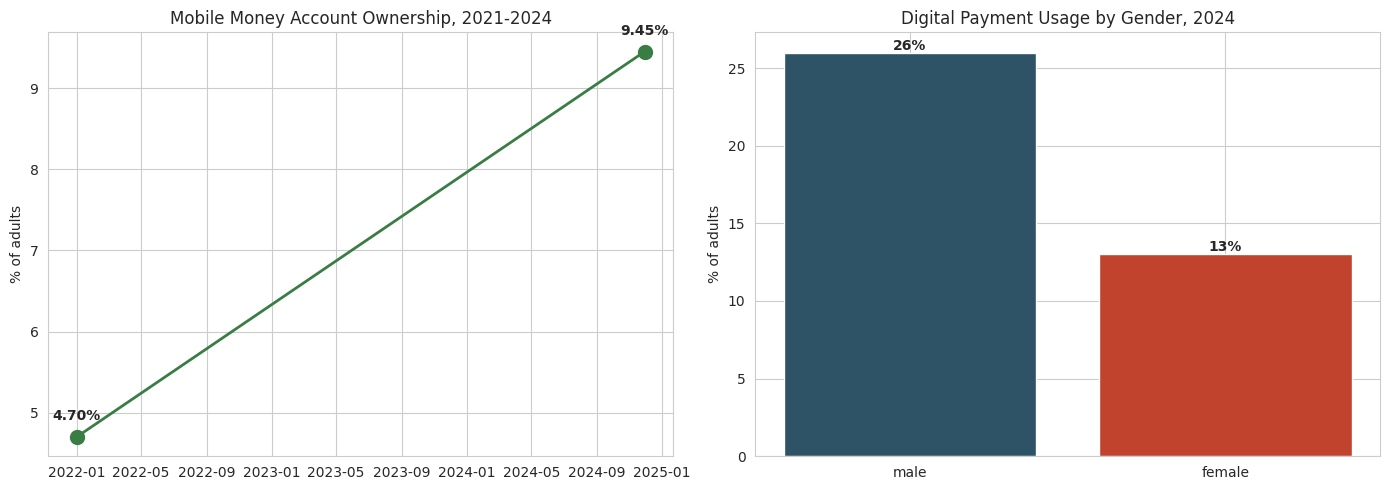

In [7]:
mm = obs[obs.indicator_code == 'ACC_MM_ACCOUNT'].copy()
mm['observation_date'] = pd.to_datetime(mm['observation_date'])
mm = mm.sort_values('observation_date')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(mm['observation_date'], mm['value_numeric'], marker='o', markersize=10, linewidth=2, color='#3A7D44')
for _, row in mm.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.2f}%", (row['observation_date'], row['value_numeric']),
                      textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold')
axes[0].set_title("Mobile Money Account Ownership, 2021-2024")
axes[0].set_ylabel("% of adults")

dp = obs[obs.indicator_code=='USG_DIGITAL_PAYMENT'].copy()
dp_plot = dp[dp.gender.isin(['male','female'])]
axes[1].bar(dp_plot['gender'], dp_plot['value_numeric'], color=['#2E5266','#C1432E'])
for i, row in dp_plot.reset_index().iterrows():
    axes[1].annotate(f"{row['value_numeric']:.0f}%", (i, row['value_numeric']), ha='center', va='bottom', fontweight='bold')
axes[1].set_title("Digital Payment Usage by Gender, 2024")
axes[1].set_ylabel("% of adults")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_usage_trends.png", bbox_inches='tight')
plt.show()

**Usage lags Access by an even wider margin than Access lags its own potential.** Mobile money account
ownership only reached 9.45% by 2024 despite Telebirr alone reporting 54.8M *registered* users
(more than half of Ethiopia's adult population) — this is the "registered vs. active" gap explored next.

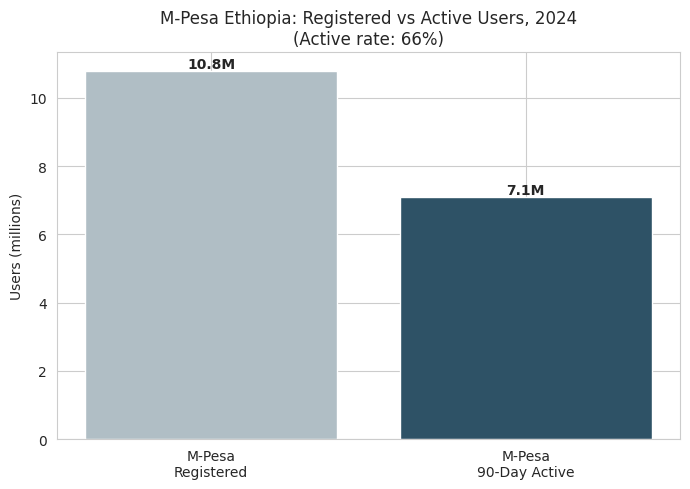

M-Pesa: 10.8M registered -> 7.1M active (66% activity rate)
Telebirr: 54.8M registered users (no active-user figure available in dataset)
Sector-wide 'Mobile Money Activity Rate' observation (REC_0025): 66%


In [8]:
# Registered vs Active gap (M-Pesa has both; Telebirr only has registered)
mpesa_reg = obs[obs.indicator_code=='USG_MPESA_USERS']['value_numeric'].values[0]
mpesa_active = obs[obs.indicator_code=='USG_MPESA_ACTIVE']['value_numeric'].values[0]
telebirr_reg = obs[obs.indicator_code=='USG_TELEBIRR_USERS']['value_numeric'].values[0]
active_rate = obs[obs.indicator_code=='USG_ACTIVE_RATE']['value_numeric'].values[0]

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(['M-Pesa\nRegistered', 'M-Pesa\n90-Day Active'], [mpesa_reg/1e6, mpesa_active/1e6], color=['#B0BEC5','#2E5266'])
for bar in bars:
    ax.annotate(f"{bar.get_height():.1f}M", (bar.get_x()+bar.get_width()/2, bar.get_height()), ha='center', va='bottom', fontweight='bold')
ax.set_title(f"M-Pesa Ethiopia: Registered vs Active Users, 2024\n(Active rate: {mpesa_active/mpesa_reg*100:.0f}%)")
ax.set_ylabel("Users (millions)")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_registered_vs_active.png", bbox_inches='tight')
plt.show()

print(f"M-Pesa: {mpesa_reg/1e6:.1f}M registered -> {mpesa_active/1e6:.1f}M active ({mpesa_active/mpesa_reg*100:.0f}% activity rate)")
print(f"Telebirr: {telebirr_reg/1e6:.1f}M registered users (no active-user figure available in dataset)")
print(f"Sector-wide 'Mobile Money Activity Rate' observation (REC_0025): {active_rate:.0f}%")

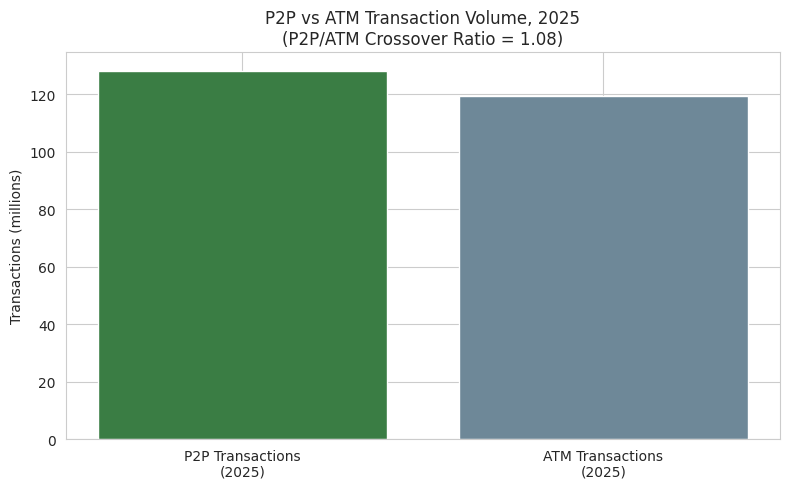

In [9]:
# P2P/ATM crossover
p2p = obs[obs.indicator_code=='USG_P2P_COUNT'].copy()
atm = obs[obs.indicator_code=='USG_ATM_COUNT'].copy()
crossover = obs[obs.indicator_code=='USG_CROSSOVER']['value_numeric'].values[0]

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(['P2P Transactions\n(2025)', 'ATM Transactions\n(2025)'],
       [p2p[pd.to_datetime(p2p.observation_date).dt.year==2025]['value_numeric'].values[0]/1e6,
        atm['value_numeric'].values[0]/1e6],
       color=['#3A7D44','#6E8898'])
ax.set_title(f"P2P vs ATM Transaction Volume, 2025\n(P2P/ATM Crossover Ratio = {crossover:.2f})")
ax.set_ylabel("Transactions (millions)")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_p2p_atm_crossover.png", bbox_inches='tight')
plt.show()

## 4. Infrastructure and Enablers

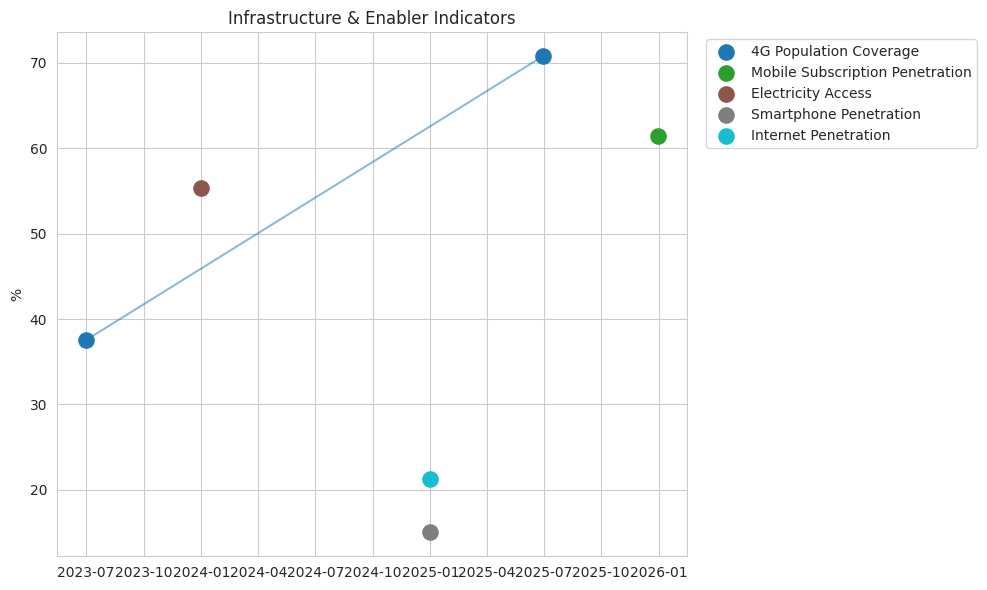

   observation_date      indicator_code  value_numeric
8        2023-06-30          ACC_4G_COV           37.5
63       2023-12-31     ACC_ELECTRICITY           55.4
64       2024-12-31  ACC_SMARTPHONE_PEN           15.0
65       2025-01-01    ACC_INTERNET_PEN           21.3
9        2025-06-30          ACC_4G_COV           70.8
10       2025-12-31      ACC_MOBILE_PEN           61.4


In [10]:
enablers = obs[obs.indicator_code.isin(['ACC_4G_COV','ACC_MOBILE_PEN','ACC_ELECTRICITY','ACC_SMARTPHONE_PEN','ACC_INTERNET_PEN'])].copy()
enablers['observation_date'] = pd.to_datetime(enablers['observation_date'])
enablers = enablers.sort_values('observation_date')

fig, ax = plt.subplots(figsize=(10,6))
labels = {
    'ACC_4G_COV': '4G Population Coverage',
    'ACC_MOBILE_PEN': 'Mobile Subscription Penetration',
    'ACC_ELECTRICITY': 'Electricity Access',
    'ACC_SMARTPHONE_PEN': 'Smartphone Penetration',
    'ACC_INTERNET_PEN': 'Internet Penetration',
}
colors = plt.cm.tab10(np.linspace(0,1,len(labels)))
for (code, label), color in zip(labels.items(), colors):
    sub = enablers[enablers.indicator_code==code]
    ax.scatter(sub['observation_date'], sub['value_numeric'], s=120, label=label, color=color, zorder=3)
    if len(sub) > 1:
        ax.plot(sub['observation_date'], sub['value_numeric'], color=color, alpha=0.5)
ax.set_title("Infrastructure & Enabler Indicators")
ax.set_ylabel("%")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(FIG_DIR / "09_infrastructure_enablers.png", bbox_inches='tight')
plt.show()
print(enablers[['observation_date','indicator_code','value_numeric']])

**The enabler stack tells a clear "leaky funnel" story:** mobile broadband/4G coverage reached 70.8%
by mid-2025, and mobile subscription penetration sits at 61.4% -- both reasonably high. But
**smartphone penetration is only 15%** and internet penetration only 21.3%. Since app-based digital
finance largely requires a smartphone (vs. USSD-based basic-phone access), this gap is a strong
candidate leading indicator for why Usage lags so far behind raw network coverage.

## 5. Event Timeline and Visual Analysis

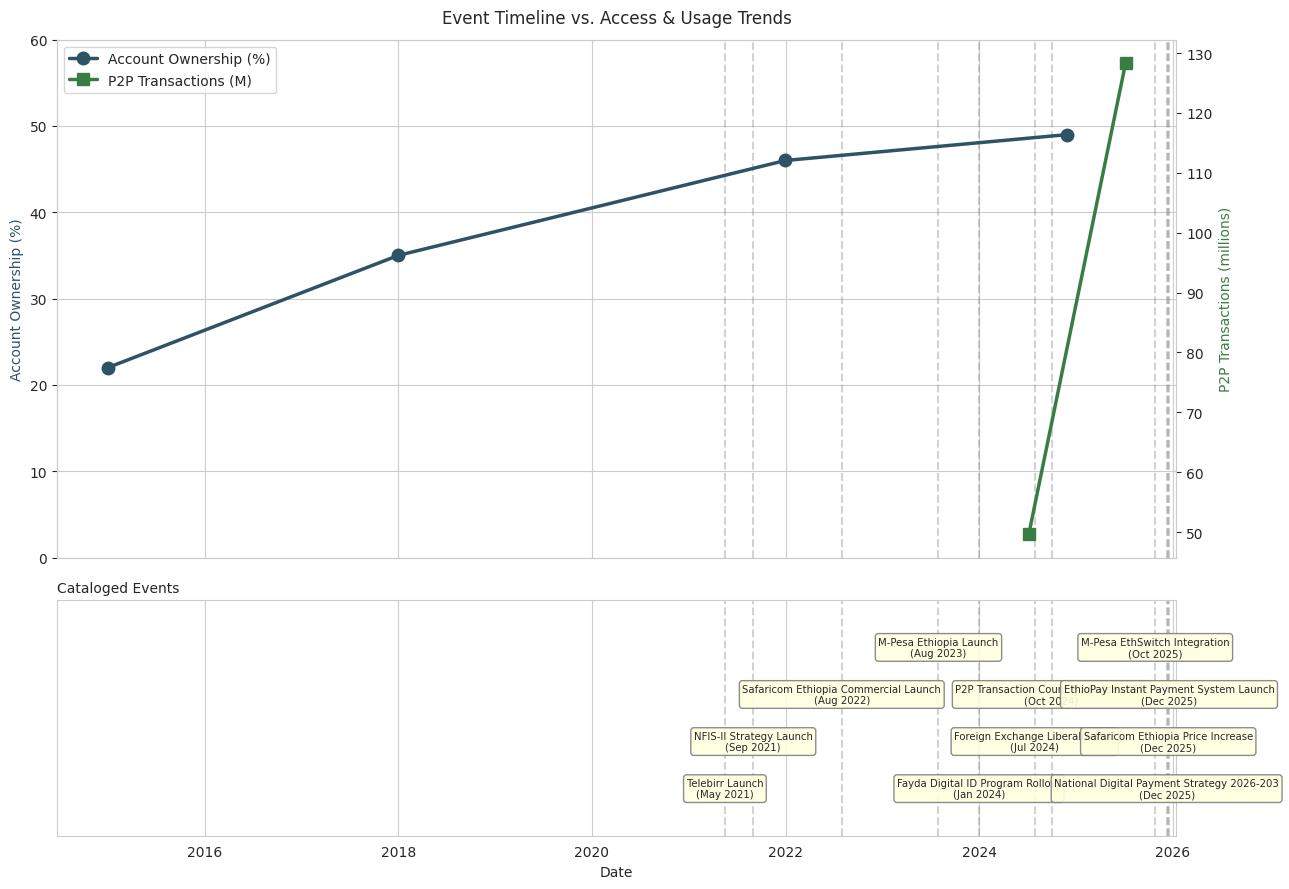

All cataloged events, chronologically:
observation_date       category                                                                                       indicator
      2021-05-17 product_launch                                                                                 Telebirr Launch
      2021-09-01         policy                                                                         NFIS-II Strategy Launch
      2022-08-01   market_entry                                                            Safaricom Ethiopia Commercial Launch
      2023-08-01 product_launch                                                                          M-Pesa Ethiopia Launch
      2024-01-01 infrastructure                                                                Fayda Digital ID Program Rollout
      2024-07-29         policy                                                                 Foreign Exchange Liberalization
      2024-10-01      milestone                                  

In [11]:
events_plot = events.copy()
events_plot['observation_date'] = pd.to_datetime(events_plot['observation_date'])
events_plot = events_plot.sort_values('observation_date').reset_index(drop=True)

fig, (ax, ax_ev) = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios': [2.2, 1]}, sharex=True)
ax2 = ax.twinx()

acc_series = acc_national.copy()
ax.plot(acc_series['observation_date'], acc_series['value_numeric'], marker='o', markersize=9, color='#2E5266', linewidth=2.5, label='Account Ownership (%)', zorder=3)
ax.set_ylabel("Account Ownership (%)", color='#2E5266')
ax.set_ylim(0, 60)

p2p_series = obs[obs.indicator_code=='USG_P2P_COUNT'].copy()
p2p_series['observation_date'] = pd.to_datetime(p2p_series['observation_date'])
ax2.plot(p2p_series['observation_date'], p2p_series['value_numeric']/1e6, marker='s', markersize=9, color='#3A7D44', linewidth=2.5, label='P2P Transactions (M)', zorder=3)
ax2.set_ylabel("P2P Transactions (millions)", color='#3A7D44')
ax2.grid(False)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax.set_title("Event Timeline vs. Access & Usage Trends", pad=12)

# Event strip below, staggered rows to avoid overlap
row_cycle = [0, 1, 2, 3]
for i, (_, ev) in enumerate(events_plot.iterrows()):
    ax.axvline(ev['observation_date'], color='gray', linestyle='--', alpha=0.35, zorder=1)
    row = row_cycle[i % len(row_cycle)]
    ax_ev.axvline(ev['observation_date'], color='gray', linestyle='--', alpha=0.35, zorder=1)
    ax_ev.annotate(f"{ev['indicator'][:42]}\n({ev['observation_date'].strftime('%b %Y')})",
                    (ev['observation_date'], row), rotation=0, fontsize=7.3, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.9))

ax_ev.set_ylim(-1, 4)
ax_ev.set_yticks([])
ax_ev.set_xlabel("Date")
ax_ev.set_title("Cataloged Events", fontsize=10, loc='left')

plt.tight_layout()
plt.savefig(FIG_DIR / "10_event_timeline.png", bbox_inches='tight')
plt.show()

print("All cataloged events, chronologically:")
print(events_plot[['observation_date','category','indicator']].to_string(index=False))

**Visual read:**
- **Telebirr launch (May 2021)** sits right before the 2021 Findex survey point, but account ownership's
  growth *rate* actually slowed in the following period (2021-24) rather than accelerating — consistent
  with the impact_link estimates (IMP_0001) suggesting a 12-month lag before effects show up, and with
  the idea that Telebirr mostly converted existing bank customers to also-mobile-money users rather than
  bringing in the unbanked.
- **M-Pesa entry (Aug 2023)** precedes the jump in P2P transaction volume (49.7M in 2024 to 128.3M in 2025,
  a 2.6x increase) — this is the clearest visual event-effect match in the dataset.
- **Safaricom's market entry (Aug 2022)** has no directly-linked Access/Usage observation immediately after
  it in the dataset (next data point is 2023 4G coverage), limiting what can be said visually about it.

## 6. Correlation Analysis

Indicators with >=3 timestamped observations (only ones where correlation is remotely meaningful):
['ACC_FAYDA', 'ACC_OWNERSHIP']


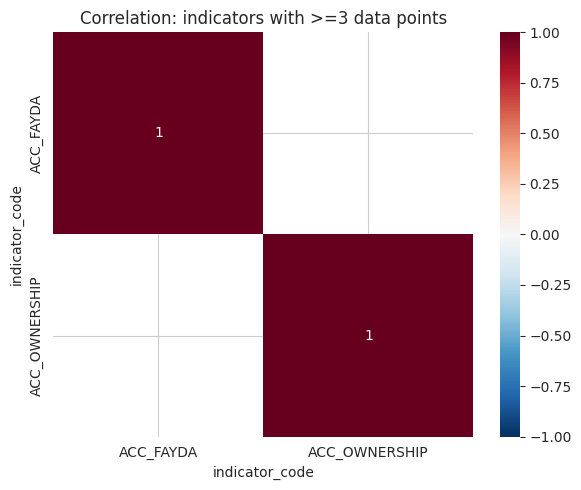

In [12]:
# Build a wide panel: for indicators with >=2 timestamped points, look at pairwise relationships
wide = obs[obs.gender=='all'].pivot_table(index='observation_date', columns='indicator_code', values='value_numeric', aggfunc='mean')
wide.index = pd.to_datetime(wide.index)
wide = wide.sort_index()

# Correlation is only meaningful with real variance & overlap -- most indicators have 1-2 points.
# Report simple pairwise correlations only where >=3 overlapping non-null timestamps exist.
corr_candidates = wide.dropna(axis=1, thresh=3)
print("Indicators with >=3 timestamped observations (only ones where correlation is remotely meaningful):")
print(corr_candidates.columns.tolist())

if corr_candidates.shape[1] >= 2:
    corr = corr_candidates.corr()
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlation: indicators with >=3 data points")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "11_correlation_heatmap.png", bbox_inches='tight')
    plt.show()
else:
    print("Fewer than 2 indicators qualify -- classic correlation analysis is not meaningful with this data volume.")

**Honest limitation:** with only 5-9 timestamped points for even the best-covered indicators, a
Pearson correlation matrix is not statistically meaningful (any two upward-trending series over time
will show spurious high correlation). We instead rely on the **impact_link table** (14 starter +
2 Task-1-added = 16 records), which encodes analyst-reviewed, sourced event-indicator relationships
with direction, magnitude, and lag — this is the appropriate substitute for correlation analysis given
the data volume, and is exactly what Task 3 formalizes into an association matrix.

In [13]:
# What impact_links say about what drives ACCESS vs USAGE
access_drivers = links[links.pillar=='ACCESS'].merge(events, left_on='parent_id', right_on='record_id', suffixes=('_link','_event'))
usage_drivers = links[links.pillar=='USAGE'].merge(events, left_on='parent_id', right_on='record_id', suffixes=('_link','_event'))

cols_to_show = ['indicator_event','impact_direction_link','impact_magnitude_link','impact_estimate_link','evidence_basis_link']
print("Events linked to ACCESS pillar (from impact_link table):")
print(access_drivers[cols_to_show].to_string(index=False))
print()
print("Events linked to USAGE pillar (from impact_link table):")
print(usage_drivers[cols_to_show].to_string(index=False))

Events linked to ACCESS pillar (from impact_link table):
                                                                                indicator_event impact_direction_link impact_magnitude_link  impact_estimate_link evidence_basis_link
                                                                                Telebirr Launch              increase                  high                  15.0          literature
                                                           Safaricom Ethiopia Commercial Launch              increase                medium                  15.0           empirical
                                                                         M-Pesa Ethiopia Launch              increase                medium                   5.0         theoretical
                                                               Fayda Digital ID Program Rollout              increase                medium                  10.0          literature
National Digital Payment Strategy

                                                                                indicator_event impact_direction_link impact_magnitude_link  impact_estimate_link evidence_basis_link
                                                                                Telebirr Launch              increase                  high                   NaN           empirical
                                                                                Telebirr Launch              increase                  high                  25.0           empirical
                                                                         M-Pesa Ethiopia Launch              increase                  high                   NaN           empirical
                                                                   M-Pesa EthSwitch Integration              increase                medium                  15.0          literature
                                                                   M-Pesa EthSwitch Integr

## 7. Key Insights and Data Quality Assessment

### Key Insight 1: Access growth is decelerating sharply, not accelerating, despite mobile money's rise
Account ownership growth fell from **4.33 pp/year (2014-17)** to **2.75 pp/year (2017-21)** to **1.00
pp/year (2021-24)** (Section 2). This directly contradicts the intuitive story that mobile money launches
(Telebirr 2021, M-Pesa 2023) should have accelerated Access. It suggests these products mostly reached
people who already had some financial access, rather than pulling in the previously unbanked — consistent
with mobile money account ownership itself staying under 10% by 2024 (Section 3).

### Key Insight 2: The gender gap is essentially frozen
Using the primary `GEN_GAP_ACC` series, the gap narrowed only **20pp → 18pp between 2021 and 2024**
(Section 2) — a 2pp improvement over three years of major digital-finance product launches. Whatever is
driving new account growth is not disproportionately reaching women.

### Key Insight 3: Usage lags Access by a wider margin than Access lags its potential
Digital payment usage sits at **21-35%** (depending on the specific Findex sub-metric — see enrichment
log) versus **49%** account ownership. The gap is starker still at the product level: Telebirr reports
**54.8M registered users** but M-Pesa's *active*-user rate is only **66%** of registered users (Section 3)
— meaning a large share of "financial inclusion" as counted by registrations does not translate into
regular usage.

### Key Insight 4: Smartphone penetration (15%), not network coverage (70.8% 4G), is the likely usage bottleneck
Mobile broadband/4G coverage and mobile subscription penetration are both over 60% (Section 4), but
smartphone penetration is only **15%** and internet penetration only **21.3%**. Since most digital-finance
apps beyond basic USSD menus require a smartphone, this is a strong candidate explanation for why Usage
lags so far behind nominal network coverage — an infrastructure story, not just an awareness or trust one.

### Key Insight 5: M-Pesa's entry coincides with the clearest visible event-effect in the whole dataset
P2P transaction volume jumped from **49.7M (2024) to 128.3M (2025)**, a 2.6x increase, following M-Pesa's
2023 launch and its 2025 EthSwitch interoperability integration (Section 5). This is the one relationship
in the dataset with both a plausible mechanism and a large, visually obvious magnitude — a good anchor
point for the Task 3 impact model's confidence calibration.

### Key Insight 6: Urban account ownership (73%) implies a large, currently unmeasured urban-rural gap
With national ownership at 49% and urban at 73% (Section 2), rural ownership must sit well below the
national average — but no direct rural Findex figure was found during Task 1 enrichment. This is a
priority data gap: the brief specifically asks about urban/rural comparison, and it currently can only be
answered indirectly.

### Data limitations (be explicit about these before modeling)
1. **Sparse time series.** Only `ACC_OWNERSHIP` has enough points (5, spanning 2011-2024) to fit any real
   trend; every other indicator has 1-2 points (Section 1). Classic correlation/regression across
   indicators is not statistically meaningful with this volume (Section 6) — the impact_link table is the
   appropriate substitute, and Task 3 should lean on it rather than on computed correlations.
2. **Conflicting secondary sources for 2024 figures.** The Task 1 enrichment log documents two specific
   conflicts: the 2024 gender gap (15pp new vs. 18pp starter-dataset) and digital payment usage (21% vs.
   the brief's ~35%). Both are kept in the dataset with `confidence: low/medium` flags rather than
   silently reconciled — Task 3/4 modeling should treat the starter dataset's own figures as primary.
3. **No rural-specific Access observation** exists yet (see Insight 6) — an explicit gap for future
   enrichment, not an oversight to paper over with an inferred number.
4. **Events without adjacent data.** Safaricom's Aug 2022 market entry has no Access/Usage observation
   in the following ~10 months, limiting what Section 5's visual analysis can say about it despite an
   impact_link estimate existing for it.
5. **A likely event near-duplicate** (NDPS 2.0 policy launch vs. EthioPay infrastructure launch, both
   Dec 2025, flagged in the enrichment log) risks double-counting effects in Task 3's association matrix
   if not resolved first.